In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
import pickle


In [18]:
df_all=pd.read_csv('umap_all_data.csv')
df_umap=pd.read_csv('umap_target_data.csv')

In [19]:
#отделяем признаки от целевой переменной и делаем ее логарифмирование
targets = ['IC50, mM', 'CC50, mM', 'SI']
all_features = [col for col in df_all.columns if col not in targets]
X_all = df_all[all_features].copy()
all_features2 = [col for col in df_umap.columns if col not in targets]
X_umap = df_umap[all_features2].copy()
y_a = df_all['CC50, mM']
y_u = df_umap['CC50, mM']

In [20]:
#делим выборку на обучающую и валидационную
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_all, y_a, test_size=0.2, random_state=42)
X_u_train, X_u_test, y_u_train, y_u_test = train_test_split(X_umap, y_u, test_size=0.2, random_state=42)


In [21]:
scaler_robust = RobustScaler()
X_a_train_r = pd.DataFrame(scaler_robust.fit_transform(X_a_train), columns=X_a_train.columns, index=X_a_train.index)
X_a_test_r = pd.DataFrame(scaler_robust.transform(X_a_test), columns=X_a_test.columns, index=X_a_test.index)

In [22]:
#т.к. целевая переменная имеет скошенное распределние (медиана сильно отличается от среднего), делаем логарифмирование
y_train_log = np.log1p(y_a_train)
y_test_log = np.log1p(y_a_test)

In [23]:
y_u_train_log = np.log1p(y_u_train)
y_u_test_log = np.log1p(y_u_test)

In [24]:
#выбираем нелинейные модели для обучения
#определяем cv для кроссвалидации
models = {'Ridge':{'model': Ridge(random_state=42),
        'params': {'alpha': [0.01, 0.1, 1, 10, 50, 100]}},
          'Lasso': {'model': Lasso(random_state=42, max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}},
          'Random Forest': {'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [200, 230, 300],
                   'max_depth': [10, 15,18],
                   'min_samples_split': [3, 4, 5],
                   'min_samples_leaf': [2, 3, 4]}},
          'Gradient Boosting': {'model': GradientBoostingRegressor(random_state=42),
        'params': {'n_estimators': [220, 250, 300],
                   'learning_rate': [0.02, 0.04, 0.06],
                   'max_depth': [3, 4, 5],
                   'subsample': [0.6, 0.8]}},
          'XGBoost': {'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {'n_estimators': [220, 250, 300],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.01, 0.03, 0.05]}},
          'LightGBM': {'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 120, 140],
            'num_leaves': [7, 9, 11],
            'learning_rate': [0.05, 0.1]}},
          'SVM': {'model': SVR(),
        'params': {'C': [10, 20, 25],
                   'gamma': ['auto', 0.1],
                   'epsilon': [0.3, 0.5]}},
          'KNN': {'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [12, 15, 18, 25],
                    'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}}}


In [25]:
#обучаем модели и сохраняем лучшие результаты
results = []
best_models = {}
print('Модели на всех признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_a_train_r, y_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_a_test_r)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на всех признаках

Ridge
Лучшие параметры: {'alpha': 100}
R² (исходная шкала): -0.1654
MAE: 466.1025
RMSE: 740.9261
CV R²: -0.0874

Lasso
Лучшие параметры: {'alpha': 10}
R² (исходная шкала): -0.2996
MAE: 509.3051
RMSE: 782.4525
CV R²: -0.0031

Random Forest
Лучшие параметры: {'max_depth': 18, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}
R² (исходная шкала): 0.2682
MAE: 332.6845
RMSE: 587.1386
CV R²: 0.3937

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 220, 'subsample': 0.6}
R² (исходная шкала): 0.2431
MAE: 355.7486
RMSE: 597.1156
CV R²: 0.3518

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
R² (исходная шкала): 0.1992
MAE: 375.2625
RMSE: 614.2114
CV R²: 0.3588

LightGBM
Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 140, 'num_leaves': 11}
R² (исходная шкала): 0.2402
MAE: 358.7710
RMSE: 598.2839
CV R²: 0.4013

SVM
Лучшие параметры: {'C': 10, 'epsilon': 0.5, 'ga

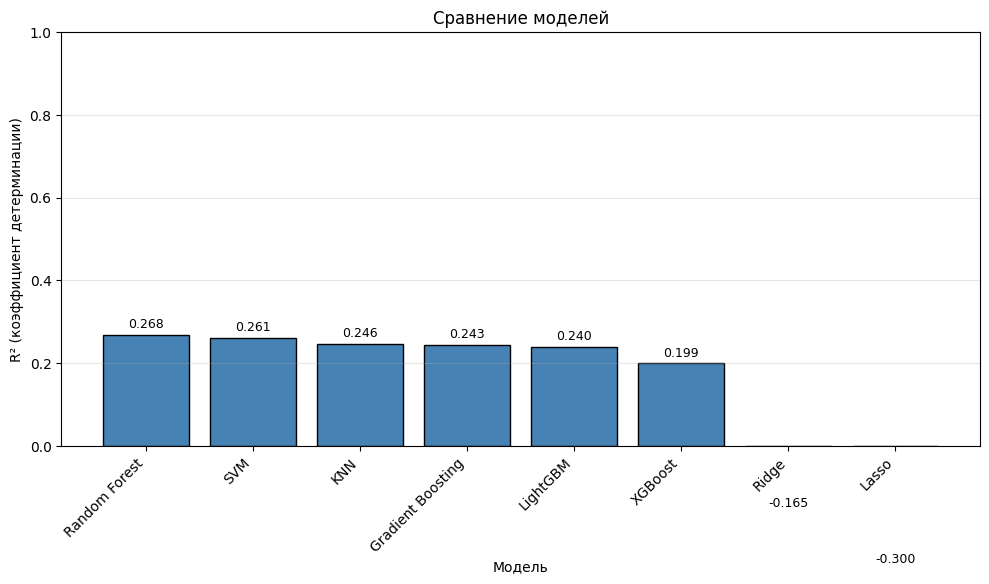

In [26]:
results = pd.DataFrame(results)
results = results.sort_values('R2', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], results['R2'], color='steelblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Модель')
plt.ylabel('R² (коэффициент детерминации)')
plt.title('Сравнение моделей')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
#проверяем модели только на UMAP признаках
results_umap = []
best_models = {}
print('Модели на UMAP признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_u_train, y_u_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_u_test)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_u_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results_umap.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на UMAP признаках

Ridge
Лучшие параметры: {'alpha': 100}
R² (исходная шкала): -0.2725
MAE: 502.1214
RMSE: 774.2268
CV R²: 0.0243

Lasso
Лучшие параметры: {'alpha': 0.01}
R² (исходная шкала): -0.2722
MAE: 502.0538
RMSE: 774.1604
CV R²: 0.0234

Random Forest
Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300}
R² (исходная шкала): 0.1878
MAE: 373.6326
RMSE: 618.5397
CV R²: 0.2015

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 220, 'subsample': 0.8}
R² (исходная шкала): 0.0794
MAE: 412.2739
RMSE: 658.5552
CV R²: 0.1557

XGBoost
Лучшие параметры: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 250}
R² (исходная шкала): 0.0873
MAE: 420.6624
RMSE: 655.7044
CV R²: 0.1629

LightGBM
Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 11}
R² (исходная шкала): 0.0832
MAE: 408.3018
RMSE: 657.1638
CV R²: 0.2106

SVM
Лучшие параметры: {'C': 10, 'epsilon': 0.5, 'ga

In [28]:
#оставляем лучшие модели и подбираем параметры более точно
param_dist = {'C': [1, 3, 5, 7, 10, 15, 20, 30, 50],
    'epsilon': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma': ['scale', 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3]}
svr = SVR()
search_svr = RandomizedSearchCV(svr, param_dist, n_iter=50, cv=9, scoring='r2', n_jobs=-1, random_state=42)
search_svr.fit(X_a_train_r, y_train_log)
best_svr = search_svr.best_estimator_
print(f'Лучшие параметры SVR: {search_svr.best_params_}')
y_pred_svr_log = best_svr.predict(X_a_test_r)
y_pred_svr = np.expm1(y_pred_svr_log)
y_true = np.expm1(y_test_log)
r2_svr = r2_score(y_true, y_pred_svr)
mae_svr = mean_absolute_error(y_true, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_true, y_pred_svr))
print('SVR')
print(f'Тест R²: {r2_svr:.4f}')
print(f'MAE: {mae_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')
print(f'CV R²: {search_svr.best_score_:.4f}')

Лучшие параметры SVR: {'gamma': 0.2, 'epsilon': 0.3, 'C': 3}
SVR
Тест R²: 0.3181
MAE: 351.75
RMSE: 566.75
CV R²: 0.3622


In [29]:
#сохраняем модель с лучшими результатами
best_svr = SVR(C=3, epsilon=0.3, gamma=0.2)
best_svr.fit(X_a_train_r, y_train_log)
y_pred_log = best_svr.predict(X_a_test_r)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)
r2_svr = r2_score(y_true, y_pred)
mae_svr = mean_absolute_error(y_true, y_pred)
rmse_svr = np.sqrt(mean_squared_error(y_true, y_pred))
print('SVR')
print(f'Тест R²: {r2_svr:.4f}')
print(f'MAE: {mae_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')

SVR
Тест R²: 0.3181
MAE: 351.75
RMSE: 566.75


In [30]:
rf_params = {'n_estimators': [200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True, False]}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search_rf = RandomizedSearchCV(rf, rf_params, n_iter=40, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=0)
random_search_rf.fit(X_a_train_r, y_train_log)
best_rf = random_search_rf.best_estimator_
print(f'Лучшие параметры RF: {random_search_rf.best_params_}')
y_pred_rf_log = best_rf.predict(X_a_test_r)
y_pred_rf = np.expm1(y_pred_rf_log)
r2_rf = r2_score(y_true, y_pred_rf)
mae_rf = mean_absolute_error(y_true, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred_rf))
print('Random Forest')
print(f'Тест R²: {r2_rf:.4f}')
print(f'MAE: {mae_rf:.2f}')
print(f'RMSE: {rmse_rf:.2f}')
print(f'CV R²: {random_search_rf.best_score_:.4f}')

Лучшие параметры RF: {'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.3, 'max_depth': 25, 'bootstrap': False}
Random Forest
Тест R²: 0.2542
MAE: 335.12
RMSE: 592.74
CV R²: 0.4054


In [31]:
#составляем ансамбль из полученных моделей
weights = [r2_svr, r2_rf]
weights = [max(0, r2_svr) + 0.1, max(0, r2_rf) + 0.1]
voting_reg = VotingRegressor(estimators=[('svr', best_svr), ('gb', best_rf)], weights=weights)
voting_reg.fit(X_a_train_r, y_train_log)
y_pred_ens_log = voting_reg.predict(X_a_test_r)
y_pred_ens = np.expm1(y_pred_ens_log)
r2_ens = r2_score(y_true, y_pred_ens)
mae_ens = mean_absolute_error(y_true, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_true, y_pred_ens))
print('Ансамбль')
print(f'Тест R²: {r2_ens:.4f}')
print(f'MAE: {mae_ens:.2f}')
print(f'RMSE: {rmse_ens:.2f}')

Ансамбль
Тест R²: 0.2889
MAE: 343.03
RMSE: 578.80


In [32]:
#сохраняем полученную модель
with open('best_reg_СС50.pkl', 'wb') as f:
    pickle.dump(best_svr, f)
with open('scaler_reg_Сc50.pkl', 'wb') as f:
    pickle.dump(scaler_robust, f)

print('Модель и компоненты сохранены в сессионное хранилище')

Модель и компоненты сохранены в сессионное хранилище


In [33]:
#проверяем загрузку
with open('best_reg_СС50.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler_reg_Сc50.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print('Модель и компоненты загружены')

Модель и компоненты загружены
